<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Chocolate_Scraping_with_Beautiful_Soup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chocolate Scraping with Beautiful Soup

After eating chocolate bars your whole life, you've decided to go on a quest to find the greatest chocolate bar in the world.

You've found a website that has over 1700 reviews of chocolate bars from all around the world. It's linked below the text for the first task.

The data is displayed in a table, instead of in a `csv` or `json`. Thankfully, we have the power of BeautifulSoup that will help us transform this webpage into a DataFrame that we can manipulate and analyze.

The rating scale is from 1-5, as described in <a href="http://flavorsofcacao.com/review_guide.html">this review guide</a>. A `1` is "unpleasant" chocolate, while a `5` is a bar that transcends "beyond the ordinary limits".

Some questions we thought about when we found this dataset were:
 - Where are the best cocao beans grown?
 - Which countries produce the highest-rated bars?
 - What's the relationship between cocao solids percentage and rating?

Can we find a way to answer these questions, or uncover more questions, using BeautifulSoup and Pandas?

In [98]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Make Some Chocolate Soup

https://content.codecademy.com/courses/beautifulsoup/cacao/index.html

List of Tags to Include: th, td, tr

List of Tags to Exclude: img, h1

*2*. Let's make a request to this stie to get the raw HTML, which we can later turn into a BeautifulSoup object.

   The URL is

```
https://content.codecademy.com/courses/beautifulsoup/cacao/index.html
```
   
 Pass this into the `.get()` method of the `requests` module to get the HTML.

In [99]:
website= 'https://content.codecademy.com/courses/beautifulsoup/cacao/index.html'
response = requests.get(website)

3. Create a BeautifulSoup object called `soup` to traverse this HTML.

   Use `"html.parser"` as the parser, and the content of the response obtained from the request as the document.

In [100]:
soup = response.content
soup = BeautifulSoup(soup, 'html.parser')

4. Print the `soup` object to explore the HTML.

In [101]:
print(soup)

<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<style>
         #cacaoTable {
         border-collapse: collapse;
         border: 2px black solid;
         font: 12px sans-serif;
         }
         #cacaoTable td {
         border: 1px black solid;
         padding: 5px;
         }
         #infoContainer {
         margin-bottom: 10px;
         display: inline-block;
         margin-right: 10px;
         }
         #chocolate {
         width: 300px;
         }
         #picContainer {
         display: inline;
         }
      </style>
</head>
<body>
<!-- <script src="http://d3js.org/d3.v3.min.js"></script> -->
<div id="banner">
<h1>Cacao Ratings</h1>
</div>
<div id="infoContainer">
<table class="infoTable">
<tr>
<td>Compiled ratings of over 1700 Chocolate bars</td>
</tr>
<tr>
<td>Ratings are from 1-5</td>
</tr>
</table>
</div>
<div id="picContainer">
<img id="chocolate" src="chocolate.jpg"/>
</div>
<table id="cacaoTable">
<tr>
<td class="Company">Company 
       

## How are ratings distributed?

5. What are the rating of all the chocolate bars? Let's make a histogram of this data.

   The first thing to do is to put all of the ratings into a list.
   
   Use a command on the `soup` object to get all of the tags that contain the ratings.

In [102]:
rating_tags = soup.find_all(attrs={'class': 'Rating'})

6. Create an empty list called `ratings` to store all the ratings in.

In [103]:
ratings = []

7. Loop through the ratings tags and get the text contained in each one. Add it to the ratings list.

   As you do this, convert the rating to a float, so that the ratings list will be numerical. This should help with calculations later.

In [104]:
# Iterate through table rows, skipping the first two (title and column headers)
for rating in rating_tags[1:]:
    rating_text = rating.get_text()
    ratings.append(float(rating_text))

print(ratings[:5])
print(len(ratings))

[3.75, 2.75, 3.0, 3.5, 3.5]
1795


8. Using Matplotlib, create a histogram of the ratings values:

```py
plt.hist(ratings)
```

   Remember to show the plot using `plt.show()`!

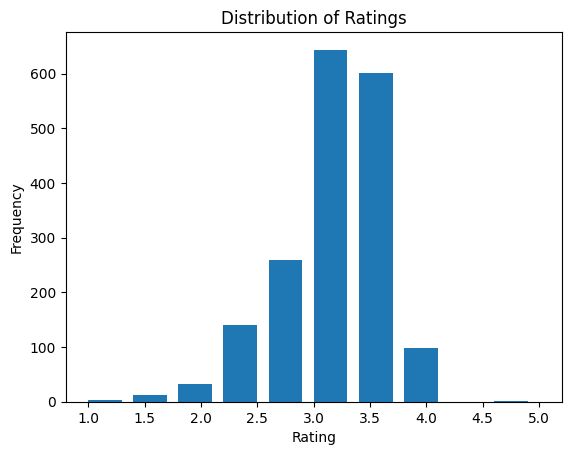

In [105]:
plt.hist(ratings, width=.3)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

## Which chocolatier makes the best chocolate?

9. We want to now find the 10 most highly rated chocolatiers. One way to do this is to make a DataFrame that has the chocolate companies in one column, and the ratings in another. Then, we can do a `groupby` to find the ones with the highest average rating.

   First, let's find all tags on the webpage that contain the company names.

In [106]:
company_tags = soup.select('.Company')
display(company_tags[:10])

[<td class="Company">Company 
                (Maker-if known)
             </td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>]

10. Just like we did with ratings, we now want to make an empty list to hold company names.

In [107]:
companies=[]

11. Loop through the tags containing the company names, and add the text from each tag to the list you just created.

In [108]:
for td in company_tags[1:]:
  companies.append(td.get_text())
len(companies)

1795

12. Create a DataFrame with a column "Company" corresponding to your companies list, and a column "Ratings" corresponding to your ratings list.

In [109]:
company_ratings = {'Company': companies, 'Ratings': ratings}
cacao_df = pd.DataFrame(company_ratings)
display(cacao_df.tail()) # Display the tail

,Company,Ratings
1790,Zotter,3.75
1791,Zotter,3.00
1792,Zotter,3.50
1793,Zotter,3.25
1794,Zotter,3.00


13. Use `.grouby` to group your DataFrame by Company and take the average of the grouped ratings.

    Then, use the `.nlargest` command to get the 10 highest rated chocolate companies. Print them out.
    
    Look at the hint if you get stuck on this step!

In [110]:
cacao_df_raw = cacao_df.copy()
cacao_mean_df = cacao_df.groupby('Company').mean()

ten_best_df = cacao_mean_df.nlargest(10, 'Ratings').sort_values('Ratings', ascending=False)
display(ten_best_df)

,Ratings
Company,
Tobago Estate (Pralus),4.000000
Heirloom Cacao Preservation (Zokoko),3.875000
Ocelot,3.875000
Amedei,3.846154
Matale,3.812500
Patric,3.791667
Idilio (Felchlin),3.775000
Acalli,3.750000
Chocola'te,3.750000


## Is more cacao better?

14. We want to see if the chocolate experts tend to rate chocolate bars with higher levels of cacoa to be better than those with lower levels of cacoa.

    It looks like the cocoa percentages are in the table under the Cocoa Percent column (note we are looking at cocoa not cocao!)
    
    Using the same methods you used in the last couple of tasks, create a list that contains all of the cocoa percentages. Store each percent as a float, after stripping off the `%` character.

In [111]:
cocoa_pwe_tags = soup.select('.CocoaPercent')
cocoa_percent =[]

for td in cocoa_pwe_tags[1:]:
  cocoa_percent.append(float(td.getText().strip('%')))

print(cocoa_percent[:5])
print(len(cocoa_percent))

[63.0, 70.0, 70.0, 70.0, 70.0]
1795


15. Add the cocoa percentages as a column called `"CocoaPercentage"` in the DataFrame that has companies and ratings in it.

In [112]:
cocoa = {'Company': companies, 'Ratings': ratings, 'CocoaPercentage': cocoa_percent}
cocoa_df = pd.DataFrame(cocoa)
display(cocoa_df.tail())

,Company,Ratings,CocoaPercentage
1790,Zotter,3.75,70.0
1791,Zotter,3.00,65.0
1792,Zotter,3.50,65.0
1793,Zotter,3.25,62.0
1794,Zotter,3.00,65.0


16. Make a scatterplot of ratings (`your_df.Rating`) vs percentage of cocoa (`your_df.CocoaPercentage`).

    You can do this in Matplotlib with these commands:
    
```py
plt.scatter(df.CocoaPercentage, df.Rating)
plt.show()
```

Call `plt.clf()` to clear the figure between showing your histogram and this scatterplot.

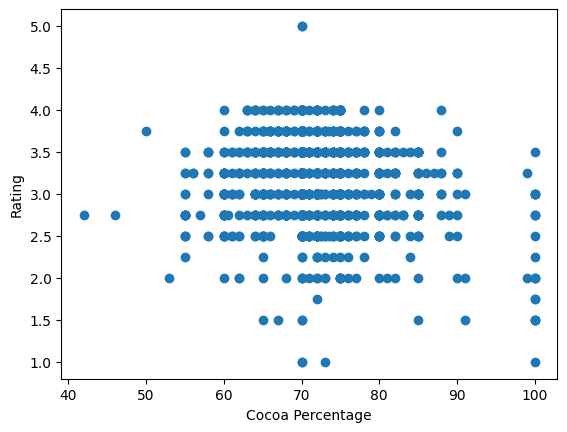

In [113]:
plt.scatter(cocoa_df.CocoaPercentage, cocoa_df.Ratings)
plt.xlabel('Cocoa Percentage')
plt.ylabel('Rating')
plt.show()


In [114]:
plt.clf()

<Figure size 640x480 with 0 Axes>

17. Is there any correlation here? We can use some numpy commands to draw a line of best-fit over the scatterplot.

    Copy this code and paste it after you create the scatterplot, but before you call `.show()`:
    
```py
z = np.polyfit(df.CocoaPercentage, df.Rating, 1)
line_function = np.poly1d(z)
plt.plot(df.CocoaPercentage, line_function(df.CocoaPercentage), "r-")
```

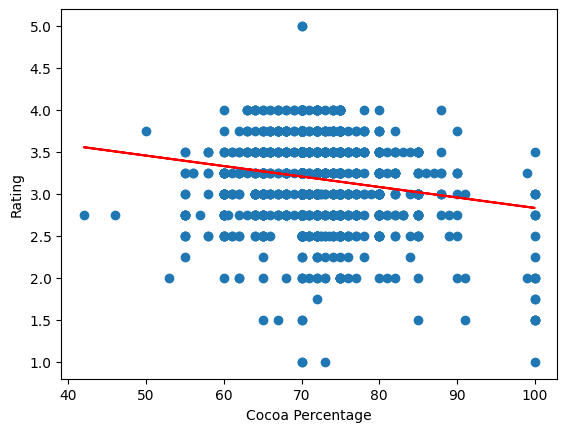

In [115]:
plt.scatter(cocoa_df.CocoaPercentage, cocoa_df.Ratings)

z = np.polyfit(cocoa_df.CocoaPercentage, cocoa_df.Ratings, 1)
line_function = np.poly1d(z)
plt.plot(cocoa_df.CocoaPercentage, line_function(cocoa_df.CocoaPercentage), "r-")
plt.xlabel('Cocoa Percentage')
plt.ylabel('Rating')
plt.show()

## Explore!

18. We have explored a couple of the questions about chocolate that inspired us when we looked at this chocolate table.

    What other kinds of questions can you answer here? Try to use a combination of BeautifulSoup and Pandas to explore some more.
    
    For inspiration: Where are the best cocoa beans grown? Which countries produce the highest-rated bars?

In [116]:
## Highest Cocoa Percentage and Their Bean Origin Countries

bean_origin_tags = soup.select('.BroadBeanOrigin')
bean_origin =[]

for td in bean_origin_tags[1:]:
  origin_country= td.getText()
  bean_origin.append(origin_country)

beans = {'Bean Origin': bean_origin, 'CocoaPercentage': cocoa_percent}
beans_df = pd.DataFrame(beans)
display(beans_df.head())

# Mean percent
mean_percent = beans_df.groupby('Bean Origin').CocoaPercentage.mean()

ten_best_origins = mean_percent.nlargest(10)
print('\n\n')
print('Highest Cocoa Percentage and Their Bean Origin Countries')
display(ten_best_origins)



,Bean Origin,CocoaPercentage
0,Sao Tome,63.0
1,Togo,70.0
2,Togo,70.0
3,Togo,70.0
4,Peru,70.0





Highest Cocoa Percentage and Their Bean Origin Countries


,CocoaPercentage
Bean Origin,
"Peru, Ecuador",99.000000
"Guat., D.R., Peru, Mad., PNG",88.000000
Samoa,85.000000
Venezuela/ Ghana,85.000000
Sao Tome & Principe,79.357143
Central and S. America,78.000000
Principe,77.000000
Carribean,76.250000
El Salvador,75.000000


In [117]:
# The top 10 best rating countries

country_origin_tags = soup.select('.CompanyLocation')

country_origins = []

for country in country_origin_tags[1:]:
  country_origins.append(country.getText())

print(len(country_origins))

country_ratings = {'Country': country_origins, 'Ratings': ratings}
country_ratings_df = pd.DataFrame(country_ratings)
best_country = country_ratings_df.groupby('Country').Ratings.mean()
display(best_country.nlargest(10))


1795


,Ratings
Country,
Chile,3.750000
Amsterdam,3.500000
Netherlands,3.500000
Philippines,3.500000
Iceland,3.416667
Vietnam,3.409091
Brazil,3.397059
Poland,3.375000
Australia,3.357143


In [118]:
country_counts = country_ratings_df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
country_counts

,Country,Count
0,U.S.A.,764
1,France,156
2,Canada,125
3,U.K.,96
4,Italy,63
5,Ecuador,54
6,Australia,49
7,Belgium,40
8,Switzerland,38
9,Germany,35


In [119]:
country_counts['Country'] = country_counts['Country'].replace({
    'U.S.A.': 'United States of America',
    'U.K.': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'Wales': 'United Kingdom',
    'Amsterdam': 'Netherlands',
    'Domincan Republic': 'Dominican Republic',
    'Eucador': 'Ecuador',
    'Niacragua': 'Nicaragua'
})

In [120]:
# Map territories to parent countries
country_counts['Country'] = country_counts['Country'].replace({
    'Puerto Rico': 'United States of America',
    'Martinique': 'France',
    'St. Lucia': 'Saint Lucia'  # if exists in shapefile
})

In [131]:
country_counts = country_counts.groupby('Country', as_index=False)['Count'].sum()

In [132]:
import plotly.express as px

fig = px.choropleth(

    country_counts,
    locations='Country', # Corrected from 'Company' to 'Country'
    locationmode='country names',
    color='Count',
    color_continuous_scale='Blues',
    title='Number of Cocoa Companies by Country'
)


fig.show()

In [135]:
merged[['NAME', 'Country']].sort_values(by='Country', ascending=False).head(10)

,NAME,Country
94,Vietnam,Vietnam
40,Venezuela,Venezuela
4,United States of America,United States of America
143,United Kingdom,United Kingdom
127,Switzerland,Switzerland
110,Sweden,Sweden
42,Suriname,Suriname
132,Spain,Spain
96,South Korea,South Korea
25,South Africa,South Africa


In [136]:
merged[['NAME', 'Country', 'Count']].head(20)

,NAME,Country,Count
0,Fiji,Fiji,4.0
1,Tanzania,NaN,NaN
2,W. Sahara,NaN,NaN
3,Canada,Canada,125.0
4,United States of America,United States of America,768.0
5,Kazakhstan,NaN,NaN
6,Uzbekistan,NaN,NaN
7,Papua New Guinea,NaN,NaN
8,Indonesia,NaN,NaN
9,Argentina,Argentina,9.0


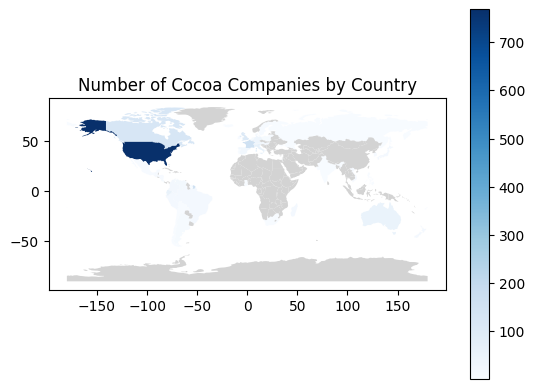

In [137]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("ne_110m_admin_0_countries.shp")
world.head()
merged = world.merge(country_counts,
                     how='left',
                     left_on='NAME',
                     right_on='Country')

merged.plot(
    column='Count',
    cmap='Blues',
    legend=True,
    missing_kwds={'color': 'lightgrey'}
)

plt.title('Number of Cocoa Companies by Country')
plt.show()